# MS Lesion Segmentation (MSLesSeg) — Runner

Notebook unico che funziona **in locale da VS Code** e **su Colab**. Rileva l'ambiente,
si posiziona nella root del repo, carica la config e ispeziona/visualizza il dataset.
Il codice vero sta in `src/` (versionato): il notebook è solo il "driver".


## 1. Ambiente + root del repo
Rileva Colab vs locale, trova la cartella del repo e la imposta come working dir.

In [1]:
import os, sys

def find_repo_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    for _ in range(8):
        if os.path.exists(os.path.join(d, "configs", "base.yaml")):
            return d
        p = os.path.dirname(d)
        if p == d:
            break
        d = p
    raise FileNotFoundError("Root del repo non trovata: apri la cartella 'ms-lesion-seg' in VS Code.")

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    # Se il repo è su GitHub, decommenta e adatta:
    # !git clone https://github.com/<TUO_UTENTE>/ms-lesion-seg.git /content/ms-lesion-seg
    # os.chdir("/content/ms-lesion-seg")

REPO = find_repo_root()
os.chdir(REPO)
if REPO not in sys.path:
    sys.path.insert(0, REPO)
print("Ambiente:", "Colab" if IN_COLAB else "Locale (VS Code)")
print("Repo root:", REPO)

Ambiente: Locale (VS Code)
Repo root: c:\Users\massi\Documents\GitHub\ms-lesion-seg


## 2. Dipendenze
In locale eseguile **una volta** nel tuo ambiente conda/venv, poi ricommenta la riga.

In [3]:
# %pip install "monai>=1.3" nibabel SimpleITK omegaconf scikit-image matplotlib pandas
# Nota: su Colab torch c'è già. In locale con GPU installa il build CUDA da pytorch.org.
import importlib.util
for m in ["omegaconf", "nibabel", "numpy", "pandas", "matplotlib"]:
    print(f"  {m}:", "OK" if importlib.util.find_spec(m) else "MANCANTE (installa)")

  omegaconf: OK
  nibabel: OK
  numpy: OK
  pandas: OK
  matplotlib: OK


## 3. Carica config + indicizza il dataset (Fase 1)
Usa i path in `configs/base.yaml`. Verifica che gli esempi di filename combacino col pattern.

In [4]:
from src.config import load_config
from src.data.indexing import discover_cases, attach_metadata, make_patient_splits
from collections import Counter

cfg = load_config("configs/base.yaml")
root = os.path.join(cfg.paths.data_root, "train")
cases = discover_cases(root, cfg.data.filename_pattern, cfg.data.modality_aliases)
cases = attach_metadata(cases, cfg.paths.metadata_csv)

n_pat = len({c["patient"] for c in cases})
print(f"Casi (train): {len(cases)} | pazienti: {n_pat}")
train, val = make_patient_splits(cases, val_fraction=0.2, seed=cfg.project.seed)
print(f"Split per paziente -> train: {len(train)} casi | val: {len(val)} casi (no leakage)")
print("\nSottogruppi:")
for k in ("sex", "age_band", "field_strength"):
    print(f"  {k}: {dict(Counter(str(c.get(k, 'NA')) for c in cases))}")

Casi (train): 93 | pazienti: 53
Split per paziente -> train: 77 casi | val: 16 casi (no leakage)

Sottogruppi:
  sex: {'F': 54, 'M': 39}
  age_band: {'18-29': 30, '30-44': 44, '45+': 19}
  field_strength: {'NA': 93}


## 4. Visualizzazione (EDA)
Slice assiale con più lesione: FLAIR, maschera e overlay. Feedback visivo immediato in VS Code.

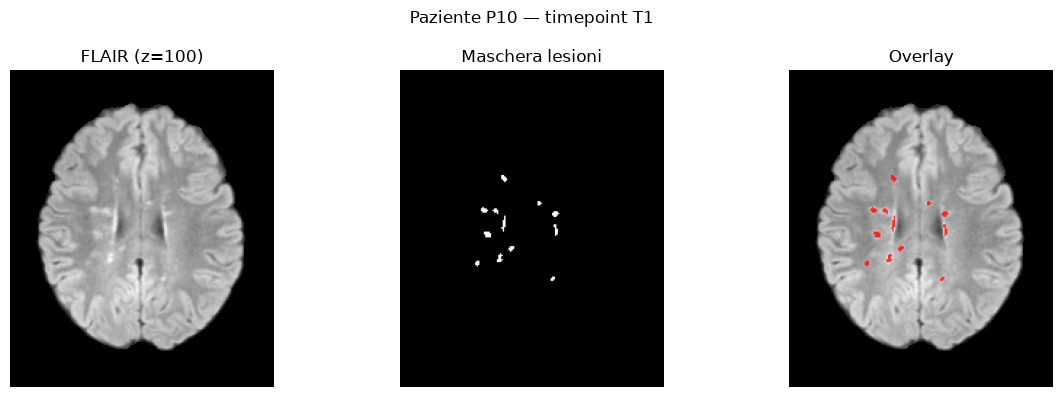

In [5]:
import numpy as np, nibabel as nib
import matplotlib.pyplot as plt

case = next(c for c in cases if c["mask"])
flair = np.asarray(nib.load(case["images"]["FLAIR"]).dataobj)
mask = np.asarray(nib.load(case["mask"]).dataobj)
z = int(np.argmax(mask.sum(axis=(0, 1))))  # slice con area lesionale massima

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(np.rot90(flair[:, :, z]), cmap="gray"); ax[0].set_title(f"FLAIR (z={z})")
ax[1].imshow(np.rot90(mask[:, :, z]), cmap="gray");  ax[1].set_title("Maschera lesioni")
ax[2].imshow(np.rot90(flair[:, :, z]), cmap="gray")
overlay = np.ma.masked_where(mask[:, :, z] == 0, mask[:, :, z])
ax[2].imshow(np.rot90(overlay), cmap="autumn", alpha=0.8); ax[2].set_title("Overlay")
for a in ax:
    a.axis("off")
plt.suptitle(f"Paziente {case['patient']} — timepoint {case['timepoint']}")
plt.tight_layout(); plt.show()

## 5. Prossime fasi
- **Fase 2** — `01_preprocess.py` (normalizzazione per-modalità → .npy) + Dataset 2.5D + transforms
- **Fase 3** — modelli (U-Net, Attention U-Net)
- **Fase 4** — loss, metriche, training (`02_train.py`)

Le celle di training/valutazione si aggiungono qui man mano che costruiamo i moduli.
Per il training pesante puoi passare a Colab senza cambiare codice: basta il path del dataset.